<center><font size=6>Personal Loan Campaign</font></center>

## Problem Statement

### Business Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and to identify which segment of customers to target more.

### Data Description

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

The data contains the different attributes of machines and health. The detailed data dictionary is given below.

**Data Dictionary**

* ID: Customer ID
* Age: Customer’s age in completed years
* Experience: # years of professional experience
* Income: Annual income of the customer (in thousand dollars)
* ZIP Code: Home Address ZIP code.
* Family: The family size of the customer
* CCAvg: Average spending on credit cards per month (in thousand dollars)
* Education: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* Mortgage: Value of house mortgage if any. (in thousand dollars)
* Personal_Loan: Did this customer accept the personal loan offered in the last campaign?
* Securities_Account: Does the customer have a securities account with the bank?
* CD_Account: Does the customer have a certificate of deposit (CD) account with the bank?
* Online: Do customers use Internet banking facilities?
* CreditCard: Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?

## Install & Importing the Necessary libraries

In [177]:
# installing uszipcode library
# Uninstall potentially incompatible versions and install specific older versions
#!pip uninstall -y uszipcode
!pip install uszipcode==0.2.6

In [178]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

from scipy import stats

# get state and other information using zipcode
from uszipcode import SearchEngine

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading AllLife Bank dataset

In [179]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [180]:
# load loan modelling.csv data into dataframe
personal_loan_data = pd.read_csv("/content/drive/My Drive/AI&ML - PG/Machine Learning/Personal Loan Campaign/Loan_Modelling.csv")

In [181]:
# copying data to another variable to avoid any changes to original data
data = personal_loan_data.copy()

## Overview of the dataset

### View the first and last 5 rows of the dataset.

In [182]:
# observe sample first 5 rows of personal data
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [183]:
# observe sample last 5 rows of personal data
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


* The `ID` column is unique key which is acting as index in dataset.
* With the `ZIPCode` don't understand the Geo-Location. Its better get **State** and other details from `ZIPCode` value using python module **uszipcode**.
* `Education` -  Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional. For label data analysis, can convert level to education values(label).
* `Personal Loan`, `securities_account`, `CD_Account`, `Online` & `Creditcard` column are boolean/ flag columns.
* for the business problem we can consider `Personal Loan` as target column.


### Get state and other details from zipcode and provide value to a new column

In [184]:
# get state , major city values from ZIPCode and create new columns for this values in dataset
search = SearchEngine()

def get_zipcode_details(zip_code):
    info = search.by_zipcode(zip_code)
    if info:
        return info.state, info.major_city
    return None, None

data[['State', 'Major_City']] = data['ZIPCode'].apply(lambda x: pd.Series(get_zipcode_details(x)))

display(data.head())

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,State,Major_City
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,CA,Pasadena
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,CA,Los Angeles
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,CA,Berkeley
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,CA,San Francisco
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,CA,Northridge


In [185]:
# create new column with Education label which contains actual values instead of keys
education_dict = {1: 'Undergrad', 2: 'Graduate', 3: 'Advanced/Professional'}

data['Education_Label'] = data['Education'].map(education_dict)

display(data.head())

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,State,Major_City,Education_Label
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,CA,Pasadena,Undergrad
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,CA,Los Angeles,Undergrad
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,CA,Berkeley,Undergrad
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,CA,San Francisco,Graduate
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,CA,Northridge,Graduate


### Understand the shape of the dataset.

In [186]:
# get no.of rows & columns from a dateset
data.shape

(5000, 17)

* The dataset has 5000 rows and 17 columns.
* last 3 columns `State` , `Major_City` derived from `ZIPCode` & `Education_Label` derived from `Education`.

### Check the data types of the columns for the dataset.

In [187]:
# info of columns datatypes non-nulls
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
 14  State               4966 non-null   object 
 15  Major_City          4966 non-null   object 
 16  Educat

**Dataset basic information:**
* The dataset has data on 5000 customers.
* We have 14 variables including 13 independent variables and 1 dependent variable which is Personal Loan. (excluded State, Major_City, Education_Label)
* We have 6 numeric variables: ID , Age , Experience , Income , CC_Avg , Mortgage
* We have 3 categorical variables: Family , Education , Zip_Code
* We have 5 Boolean variables: Personal_Loan , Securities Account , CD_Account , Online , Credit_Card
* There are no duplicates in the dataset.
* Other 'derived columns (State & Major_City)', there are no missing values

* `CCAvg` column datatype is `float` and other columns datatype is `int`
* last 3 columns `State,Major_City, Education_label` which are derived from other columns `Object`


### Checking for missing values

In [188]:
# checking for null values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


* There are **34 null** values present in `State` & `Major_City` which are derived from `ZIPCode`. However, in `ZIPCode` there is **no null** values present.  
* Hence, we can assume that **uszipcode** python module is not up-to-date with other ZIPCodes which is providing null values.

### Handling Missing Values

In [189]:
# as state, major_city null values proper records as ZIPCode is available.
data['State'].fillna('Unknown', inplace=True)
data['Major_City'].fillna('Unknown', inplace=True)

# Verify null values are handled
display(data.isnull().sum())

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0




*   Replaced Null values to `Unknown` in State & Major_City columns. AS there valid records due to ZIP_Code value present.



### Dropping the duplicate values

In [190]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

#### Dropping the columns with all unique values

In [191]:
data.ID.nunique()

5000

* The `ID` column contains only unique values, so we can drop it

In [192]:
data = data.drop(["ID"], axis=1)

### Statistical summary of the data

**Let's check the statistical summary of the data.**

In [193]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


* `Age`: Customers range from 23 to 67 years old, with an average age of about 45. The distribution seems fairly centered with a standard deviation of 11.46 years.

* `Experience`: The experience ranges from -3 to 43 years, with an average of around 20 years. The presence of negative experience values (-3 years) suggests a data quality issue that might need addressing, as experience cannot be negative.

* `Income`: Customer incomes range from 8,000 to 224,000 dollars (as income is in thousand dollars), with a mean of 73,774 dollars. There's a relatively large standard deviation (46,033 dollars), indicating a wide spread in income levels.

* `ZIPCode`: This is a geographical identifier, not a truly numerical feature for statistical analysis like mean or standard deviation. Its range is from 90005 to 96651.

* `Family`: Family sizes range from 1 to 4 members, with an average of 2.4 members.

* `CCAvg (Average Credit Card Spending)`: Monthly credit card spending ranges from 0 to 10,000 dollars (in thousand dollars), with an average of 1,937 dollars. The max value (10) indicates some customers have very high spending.

* `Education`: This is a categorical variable encoded as 1, 2, 3. The mean of 1.88 suggests a leaning towards 'Undergrad' and 'Graduate' levels.

* `Mortgage`: The mortgage values range from 0 to 635,000 dollars. The 75th percentile is 101,000 dollars, but the mean is 56,498 dollars, and the median is 0, indicating that a significant portion of customers do not have a mortgage.

* `Personal_Loan`: The mean is 0.096, which means approximately 9.6% of customers accepted the personal loan offer. This highlights that the target variable is imbalanced, with far fewer loan acceptors than non-acceptors.

* `Securities_Account`: Approximately 10.44% of customers have a securities account.

* `CD_Account`: About 6.04% of customers have a CD account.

* `Online`: Around 59.68% of customers use online banking facilities.

* `CreditCard`: Approximately 29.4% of customers use a credit card issued by another bank.

### Treatment - incorrect Values of `Experience`

The dataset contains negative values for Experience. Considering that the values of this feature indicate work experience in years, these negative values are considered noise:

In [194]:
# get count of negative Experience records in dataset
data[data['Experience']<0]['Experience'].count()

np.int64(52)

Had 52 negative experience records in dataset

In [195]:
# Get unique negative value counts
data[data['Experience']<0]['Experience'].value_counts()

,count
Experience,
-1,33
-2,15
-3,4


Since the number of these negative values in the Experience feature is small, we assume that these values are incorrectly recorded as negative and replace them with their absolute value:

In [196]:
# Apply absolute value to experience column
data['Experience'] = data['Experience'].apply(abs)

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>

### **Note**: We will mainly focus on the model building aspects. We will only be looking at the key observations from EDA.

**The below functions need to be defined to carry out the EDA.**

In [197]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [198]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [199]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [200]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

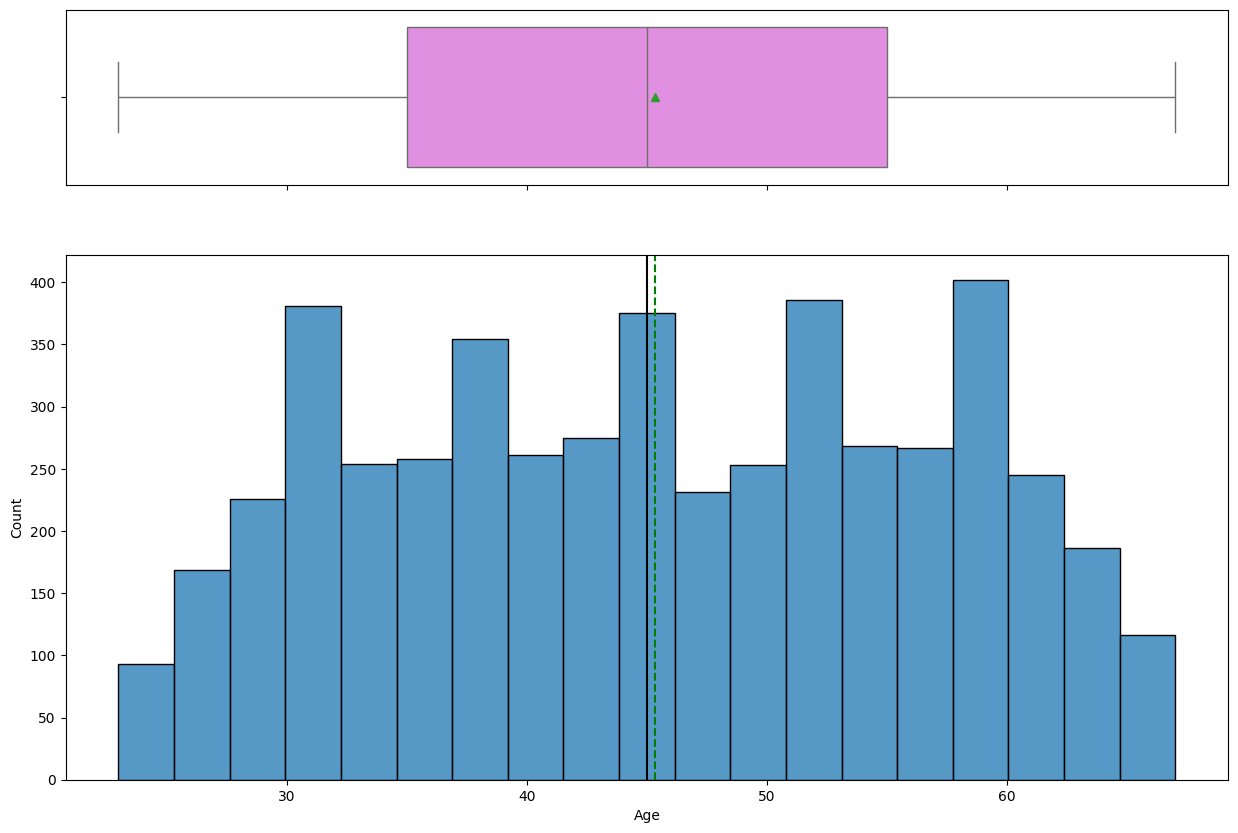

In [201]:
histogram_boxplot(data, "Age")

* There is no outlier present in column `Age`.
* Mean & Median age respectively 45.34 & 45 years,
* It is fairly symmetrical, leaning neither left or right.

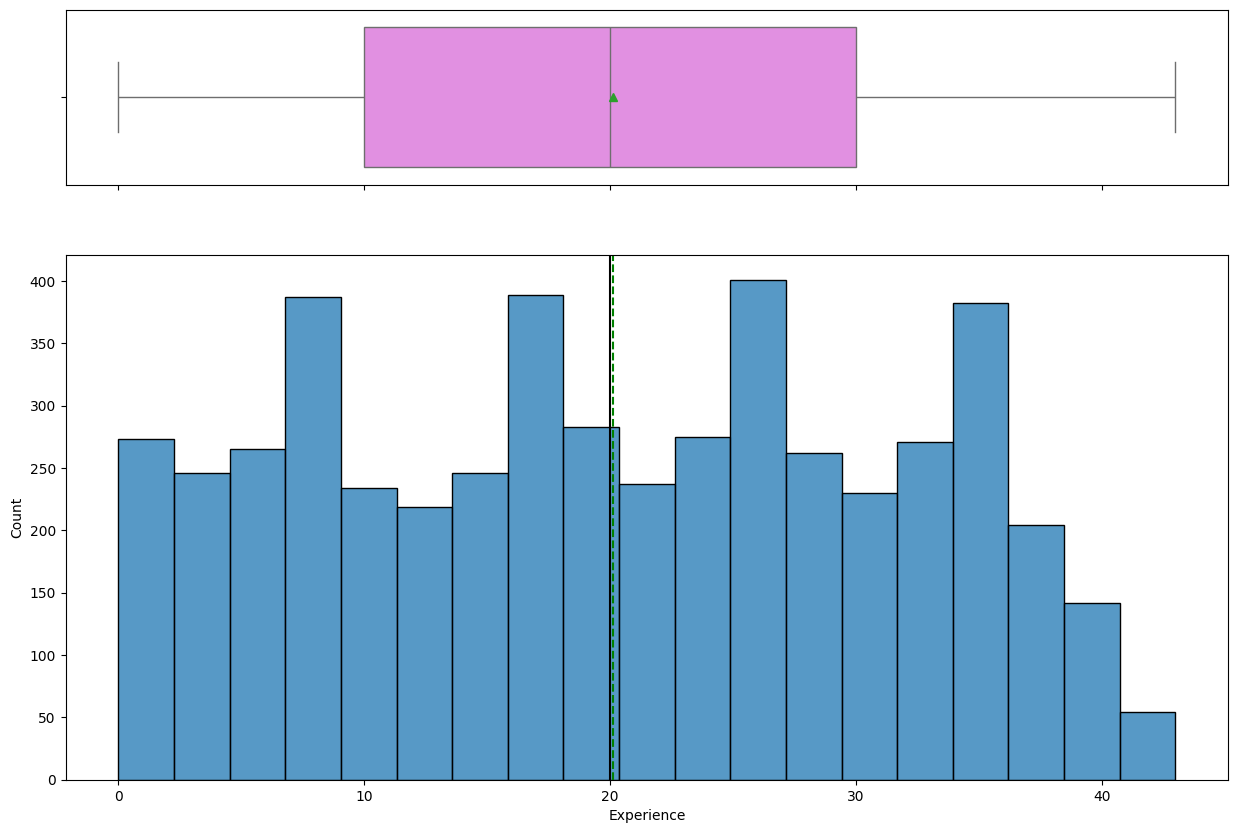

In [202]:
histogram_boxplot(data, "Experience")

* There is no outlier present in column `Experience`.
* Mean & Median age respectively 20.10 & 20 years,
* It is fairly symmetrical, leaning neither left or right.

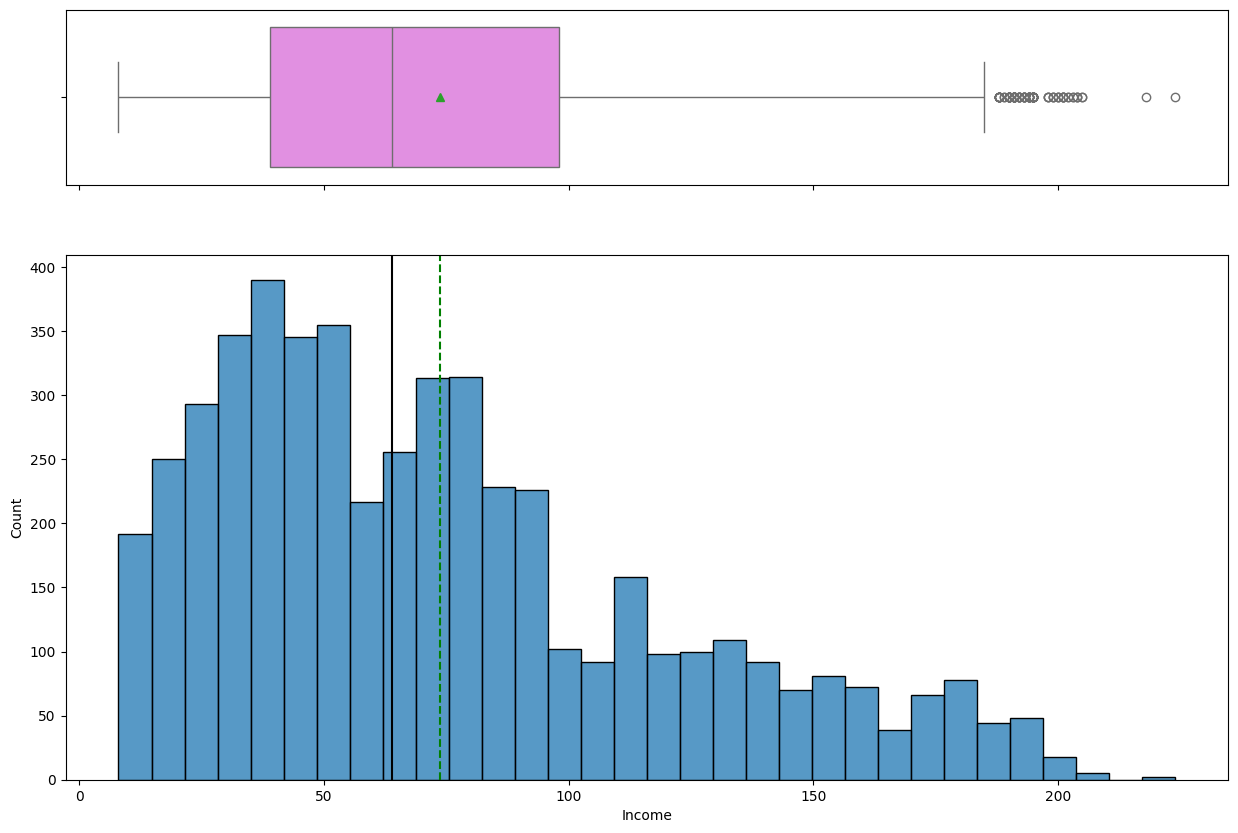

In [203]:
histogram_boxplot(data, "Income")

* **Mean and Median**: The mean income is approximately 73.77 thousand dollars, while the median income is 64.0 thousand dollars.
* **Skewness**: The distribution of Income is right-skewed, meaning there are a few customers with significantly higher incomes.
* **Outliers**: The boxplot likely shows several outliers on the upper end, which is consistent with a right-skewed income distribution where some individuals earn considerably more than the majority.

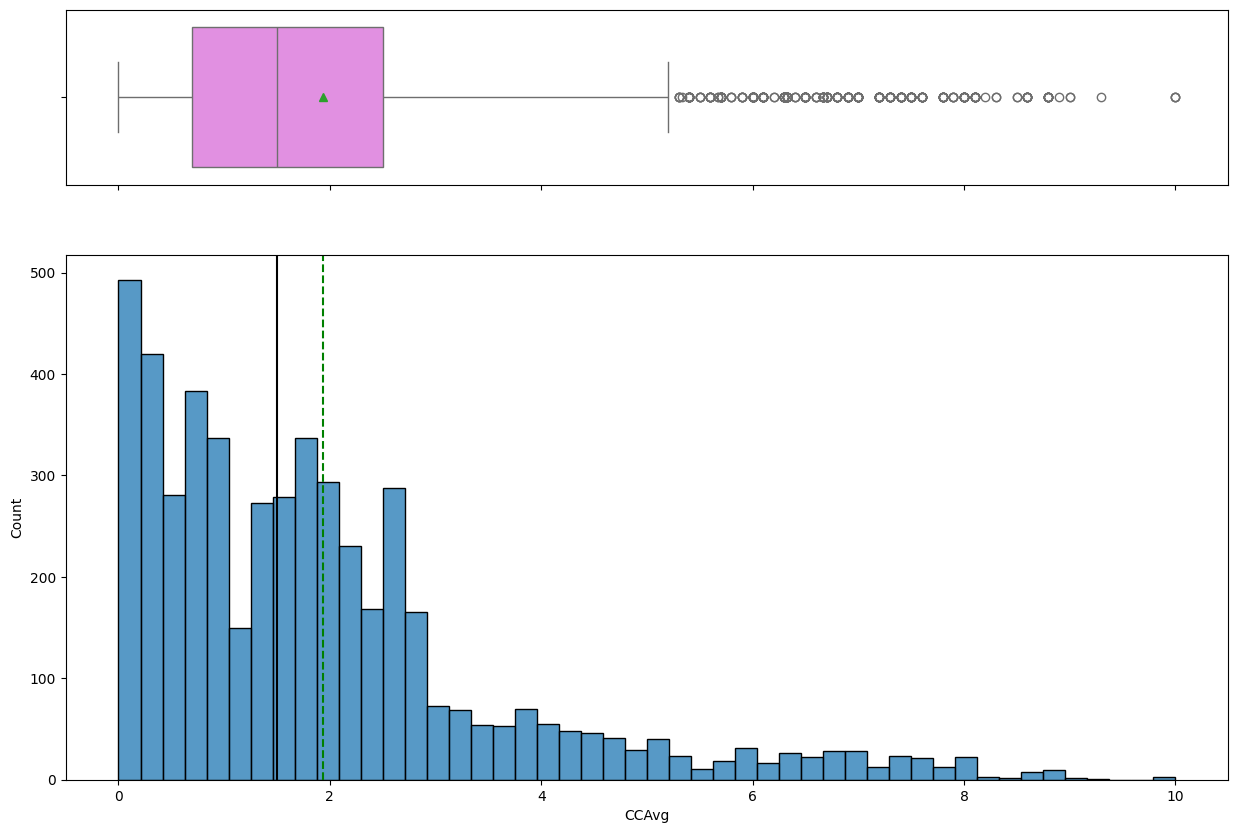

In [204]:
histogram_boxplot(data, "CCAvg")

*  **Mean and Median**: The mean `CCAvg` is approximately 1.94 thousand dollars, while the median is 1.5 thousand dollars.
* **Skewness**: The distribution of CCAvg is right-skewed. This indicates that most customers have lower credit card spending, but there are a few customers with significantly higher spending.
* **Outliers**: Above representation shows several outliers on the upper end, consistent with a right-skewed distribution where some individuals spend considerably more on their credit cards than the majority.

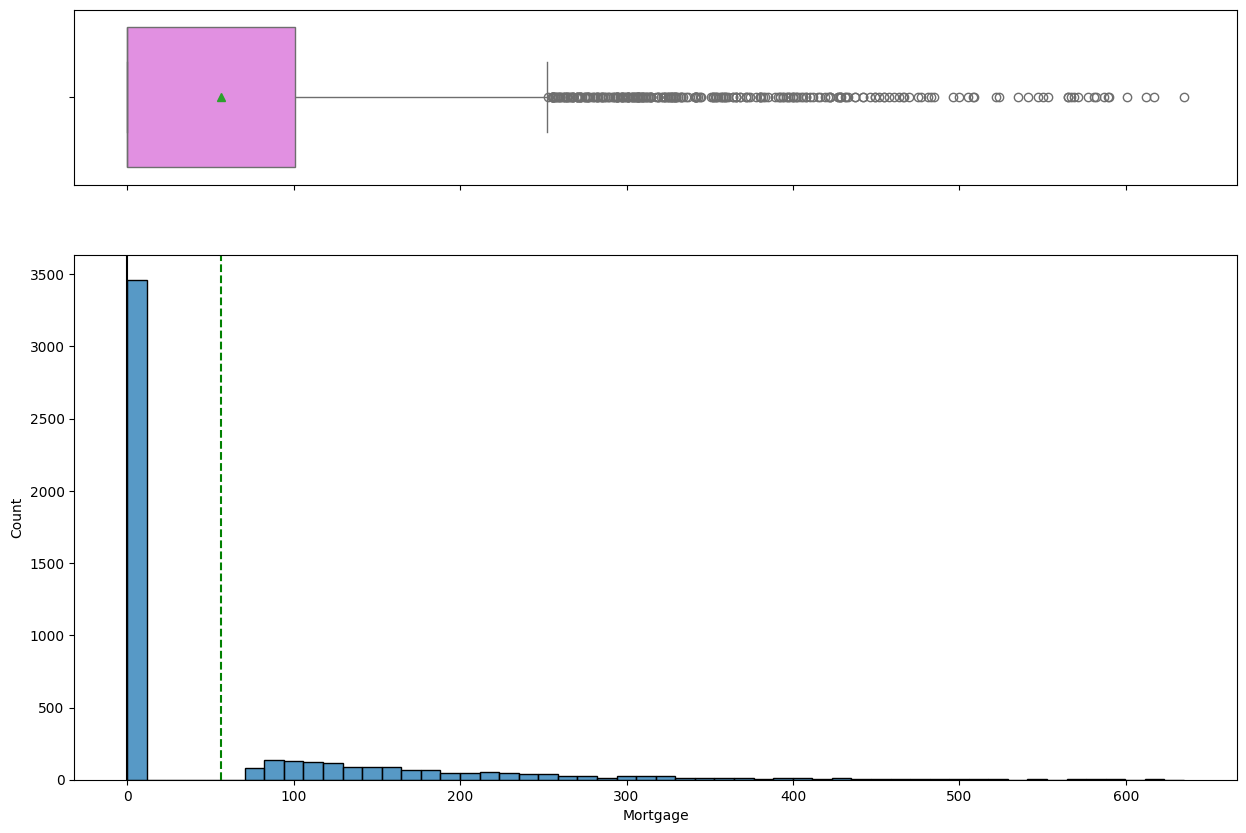

In [205]:
histogram_boxplot(data, "Mortgage")

* **Mean and Median**: The mean mortgage value is approximately 56.5 thousand dollars, but the median is 0.
* **Skewness**: The distribution of Mortgage is highly right-skewed. This is because a significant portion of customers (at least 50%) have no mortgage, and there are a few customers with very high mortgage values, pulling the mean up.
* **Outliers**: Above representation showing substantial number of outliers on the upper end, reflecting the customers with large mortgage values, which are far from the median of zero.

### Conclusion - Numeric variable Analysis

* `CCAvg` & `Mortgage` are having outliers.
* `Mortgage` is having more outliers. Need to do more analysis for this about dealing with outliers.

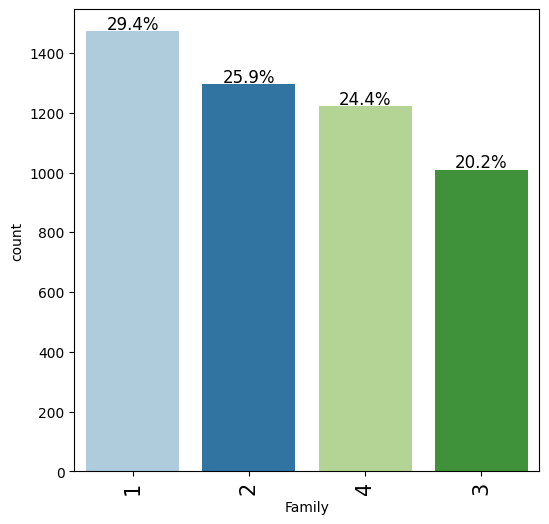

In [206]:
labeled_barplot(data, "Family", perc=True)

* A significant portion of customers, specifically more than 55%, are from families with either 1 or 2 members.
* This distribution suggests that smaller family sizes are more prevalent in the dataset, which could be an important factor in understanding personal loan eligibility or need.

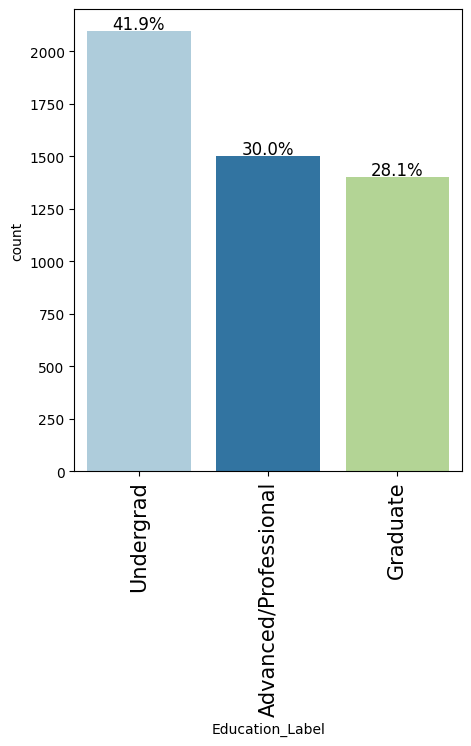

In [207]:
# Instead of Education varaible use Education_Label araible for better understanding with names instead of Keys.
labeled_barplot(data, "Education_Label", perc=True)

* Around 42% customers are Undergrad
* 70% customers are Undergrad & Graduates
* 30% are Professional/Advanced.

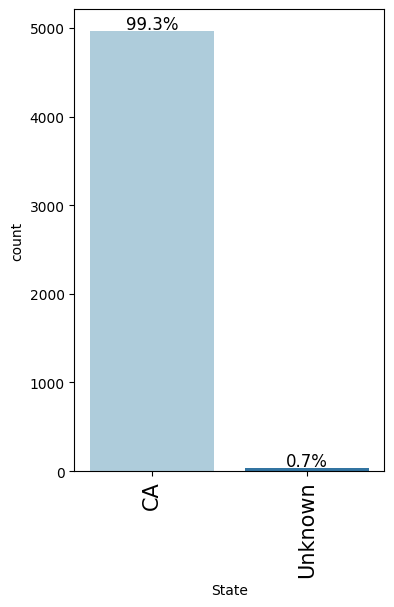

In [208]:
# instead of ZIPCode analyze using State & Major_City varaibles.

labeled_barplot(data, "State", perc=True)

* 99.3% customers are from California (CA)  and remaining are 0.7% are from Unknown. Then we can safely assume all customers are from CA.



In [209]:
labeled_barplot(data, "Major_City", perc=True)

* `Major_City` is having lot of unique values. We can ignore Major_City varaible in model.
* **Los Angeles** having more customers with 7.5%.

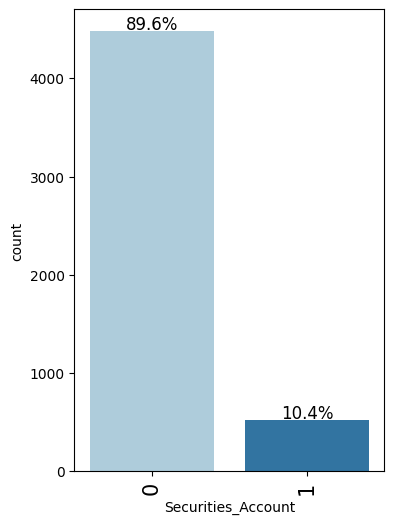

In [210]:
#
labeled_barplot(data, "Securities_Account", perc=True)

* Only approx 10% customers are having SecuritiesAccount with the Bank

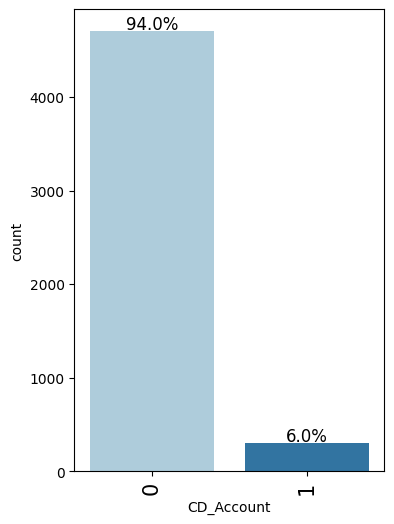

In [211]:
labeled_barplot(data, "CD_Account", perc=True)

* 6% customers having CD Account in bank

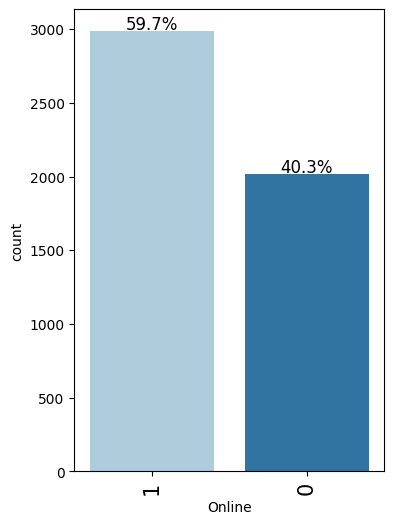

In [212]:
labeled_barplot(data, "Online", perc=True)

* 59.7% customers are activated/using Online banking

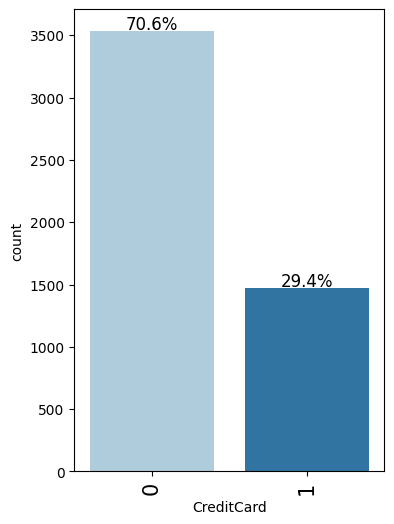

In [213]:
labeled_barplot(data, "CreditCard", perc=True)

* 29.4% customers are having CreditCard with the bank.

### Conclusions -  Categorical Variables

* 29.4% customers are single.
* 41.9% customers are undergrad.
* 9.6% bought a personal loan from the bank.
* 10.4% customers have a securities account with the bank
* 6% customer have a CD account.
* 60% customers transact online.
* 29.4% customers have credit cards.
* 75% of customers are in range of 31- 60.

### Outlier Treatment

Mortgage is having outliers, Will use **ZScore** to identify the number of outlier records for Mortgage.

`ZScore` method for outlier detection is a statistical technique used to detect outliers from data sets by calculating how many standard deviations away from the mean each data point is. A data point with a Z score of more than 3 standard deviation away from the mean is considered an outlier. We use the scipy.stats module to perform the zscore technique:

In [214]:
#Identify the Mortgage Outlier records using ZScore
data[stats.zscore(data['Mortgage'])>3]['Mortgage'].count()

np.int64(105)

In [215]:
data[stats.zscore(data['Mortgage'])>3]

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,State,Major_City,Education_Label
42,32,7,132,90019,4,1.1,2,412,1,0,0,1,0,CA,Los Angeles,Graduate
59,31,5,188,91320,2,4.5,1,455,0,0,0,0,0,CA,Newbury Park,Undergrad
119,32,7,112,94304,1,4.6,1,366,0,0,0,0,0,CA,Palo Alto,Undergrad
288,44,19,172,94306,2,4.3,3,391,1,1,1,1,0,CA,Palo Alto,Advanced/Professional
303,49,25,195,95605,4,3.0,1,617,1,0,0,0,0,CA,West Sacramento,Undergrad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4672,52,26,180,95831,1,1.7,1,550,0,0,0,1,0,CA,Sacramento,Undergrad
4698,48,22,162,94143,3,1.4,1,400,1,0,0,0,0,CA,San Francisco,Undergrad
4812,29,4,184,92126,4,2.2,3,612,1,0,0,1,0,CA,San Diego,Advanced/Professional
4842,49,23,174,95449,3,4.6,2,590,1,0,0,0,0,CA,Hopland,Graduate


We found 105 records with a Z-score mortgage value greater than 3. Therefore, we consider these 105 records as outliers.
Mortgage of a home can be taken only by few customers. Hence even these 105 are outliers, Will consider them in data model.


### Outlier Treatment for CDAvg

In [216]:
# Get no.of outliers for CCAvg using ZScore
data[stats.zscore(data['CCAvg'])>3]['CCAvg'].count()

np.int64(121)

In [217]:
# display sample records of CCAvg outlier
data[stats.zscore(data['CCAvg'])>3].head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,State,Major_City,Education_Label
9,34,9,180,93023,1,8.9,3,0,1,0,0,0,0,CA,Ojai,Advanced/Professional
18,46,21,193,91604,2,8.1,3,0,1,0,0,0,0,CA,Studio City,Advanced/Professional
55,41,17,139,94022,2,8.0,1,0,0,0,0,1,0,CA,Los Altos,Undergrad
131,58,34,149,93720,4,7.2,2,0,1,0,1,1,1,CA,Fresno,Graduate
145,59,35,124,90007,1,7.4,1,0,0,0,0,0,1,CA,Los Angeles,Undergrad


We found 121 records with a Z-score Average Credit Card bill value greater than 3. Therefore, we consider these 105 records as outliers.
As most of customers are not having credit card and these customers Credit card will be default 0
Hence even these 105 are outliers, Will consider them in data model.

### Feature Engineering

In the dataset, CCAVG represents average monthly credit card spending, but Income represents the amount of annual income. To make the units of the features equal, we convert average monthly credit card spending to annual

In [218]:
# convert Average Credit card units to 12 months/ Annual similar to Income which on Annual.
data['CCAvg'] = data['CCAvg']*12

In [219]:
data.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,State,Major_City,Education_Label
0,25,1,49,91107,4,19.2,1,0,0,1,0,0,0,CA,Pasadena,Undergrad
1,45,19,34,90089,3,18.0,1,0,0,1,0,0,0,CA,Los Angeles,Undergrad
2,39,15,11,94720,1,12.0,1,0,0,0,0,0,0,CA,Berkeley,Undergrad
3,35,9,100,94112,1,32.4,2,0,0,0,0,0,0,CA,San Francisco,Graduate
4,35,8,45,91330,4,12.0,2,0,0,0,0,0,1,CA,Northridge,Graduate


### Bivariate Analysis

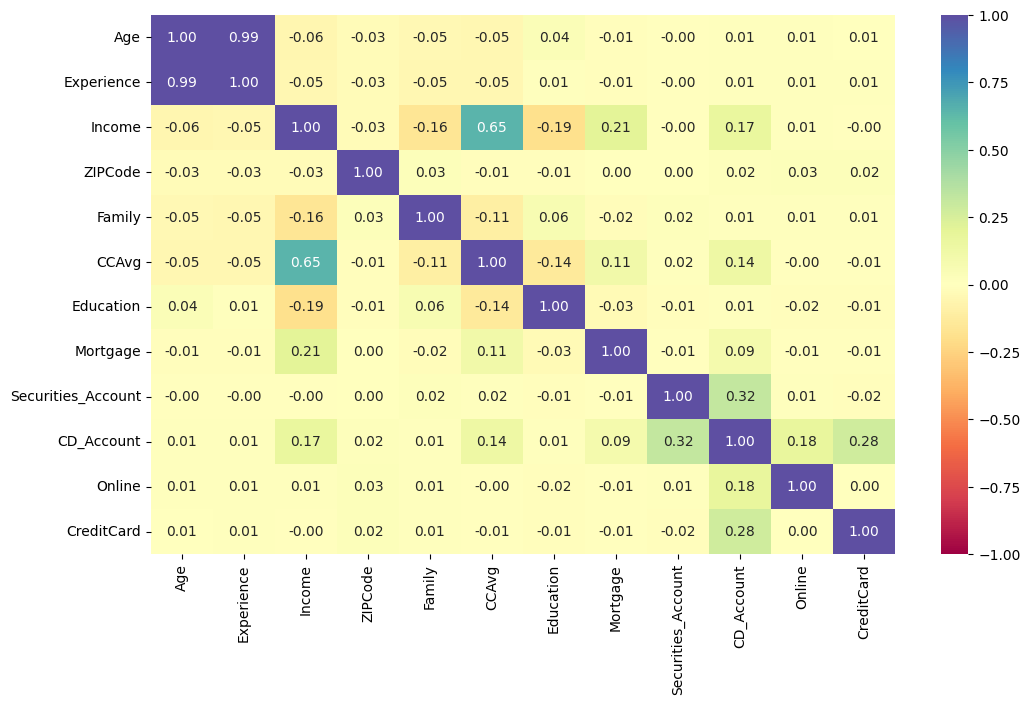

In [220]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()
cols_list.remove('Personal_Loan')

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

* There's a strong positive correlation between the `Age` and `Experience`.
* There's a positive correlation between the `CCAvg` and `Income`.
* No other variables are correlated. We will analyze it further.

**Let's see how the target variable varies across the category varaibles**

Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


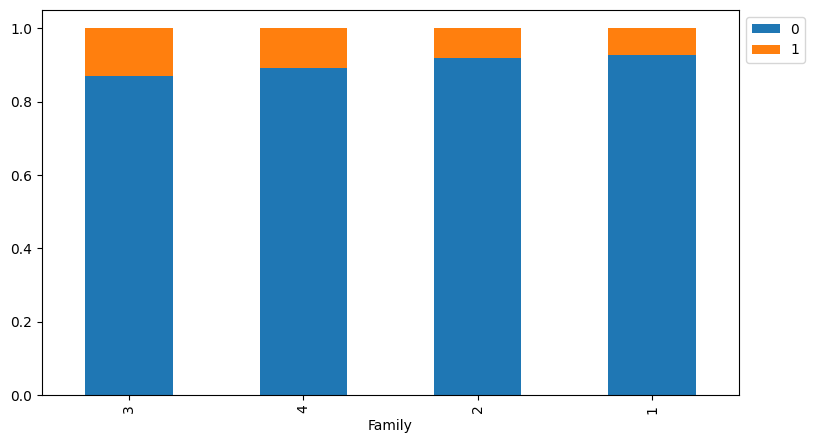

In [221]:
stacked_barplot(data, "Family", "Personal_Loan")

* Observed customers with 3 or 4 family members are likely to take personal loan more compare to customers with 1 or 2 family members

Personal_Loan             0    1   All
Education_Label                       
All                    4520  480  5000
Advanced/Professional  1296  205  1501
Graduate               1221  182  1403
Undergrad              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


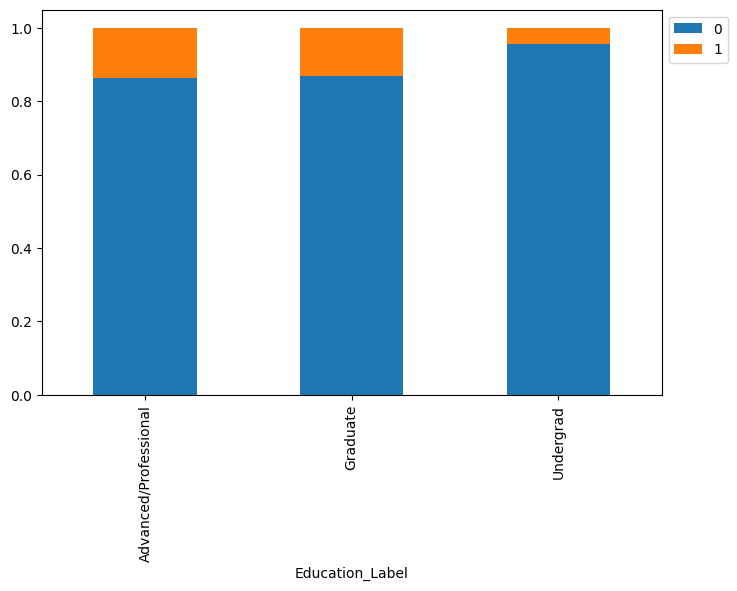

In [222]:
stacked_barplot(data, "Education_Label", "Personal_Loan")

Customers with Professional or Graduate Education is likely take perosnal loan compare to Undergrads

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


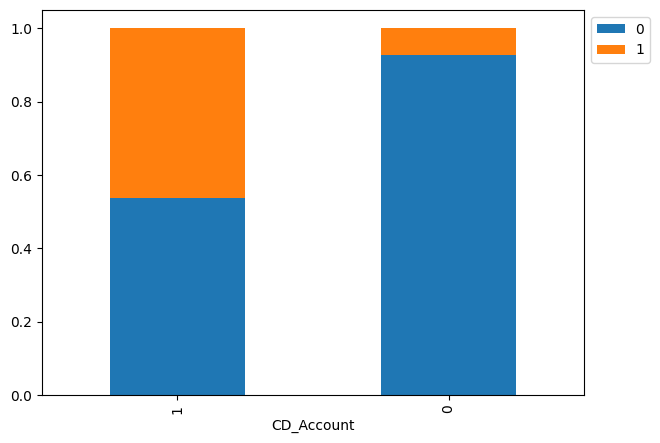

In [223]:
stacked_barplot(data, "CD_Account", "Personal_Loan")

Customers with CD Account is likely take perosnal loan compare to customers without CD Account

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


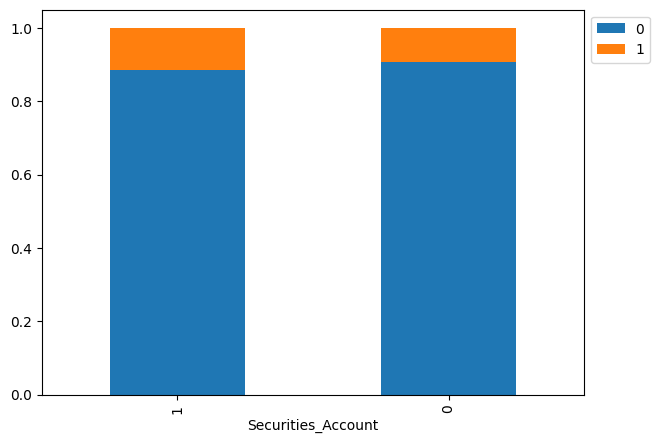

In [224]:
stacked_barplot(data, "Securities_Account", "Personal_Loan")

Customers who have a securities account with the bank are slightly more likely to accept a personal loan offer compared to those who do not have a securities account.

Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


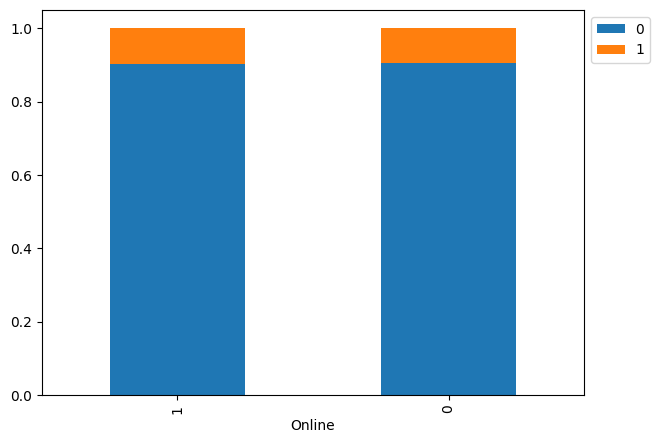

In [225]:
stacked_barplot(data, "Online", "Personal_Loan")

Customers who use internet banking facilities have a slightly higher personal loan acceptance rate compared to those who do not use internet banking. The difference is minimal, suggesting that internet banking usage might not be a strong predictor of personal loan acceptance on its own

Personal_Loan     0    1   All
CreditCard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


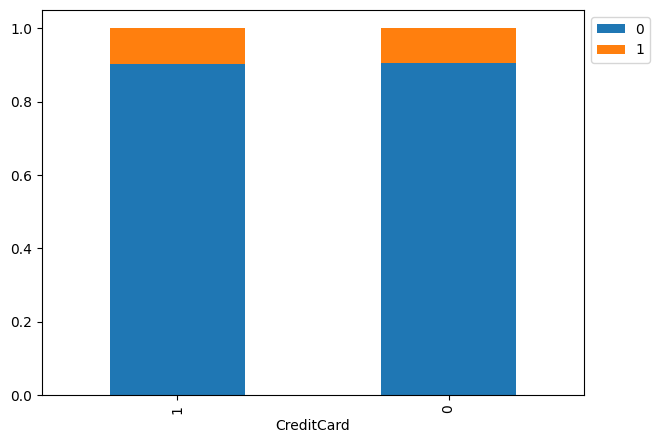

In [226]:
stacked_barplot(data, "CreditCard", "Personal_Loan")

The personal loan acceptance rates for customers who use a credit card and those who do not are very similar. This suggests that the presence or absence of a credit card does not significantly impact the likelihood of a customer accepting a personal loan

`Conclusion`

* The customer who has a `CD Account` with the bank **appears to buy personal loans from the bank**.

* Customers with **higher levels of education** are **more likely to buy** personal loans.

* The **number of family members has no significant effect** on the probability of buying personal loans.

* Customers who have or do not have a **securities account** at the bank have **no influence** on the probability of buying a personal loan.

* The customers **internet banking (online) does not seem to have any influence** on the probability of buying a personal loan.

* The customer who uses or does not use a **credit card does not appear to have an impact** on the likelihood of purchasing a personal loan.

**Let's analyze the relation between `Income` and `Personal Loan`.**

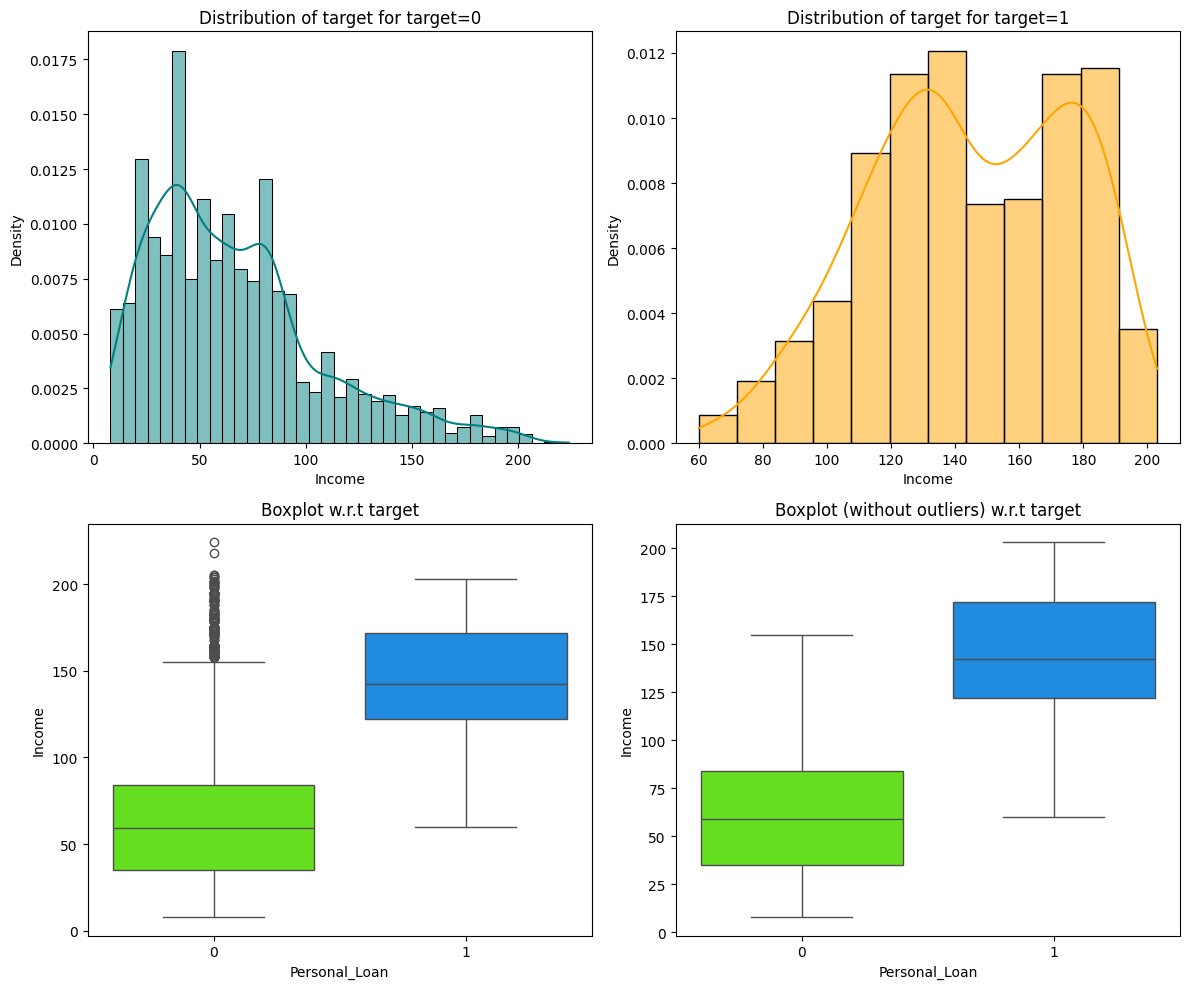

In [227]:
distribution_plot_wrt_target(data, "Income", "Personal_Loan")

* Customers with High Income are more likely.

**Let's analyze the relation between `CCAvg` and `Personal Loan`.**

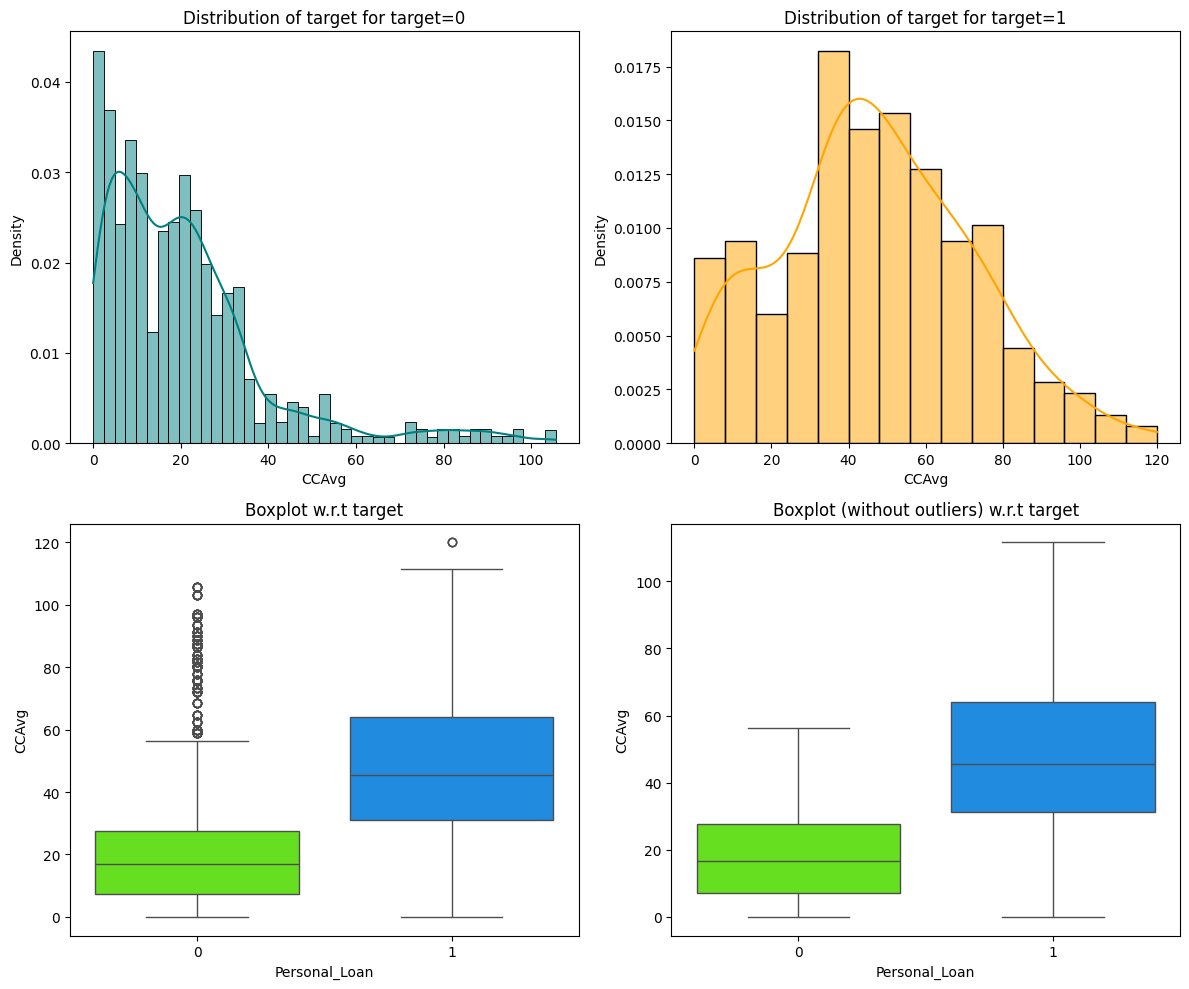

In [228]:
distribution_plot_wrt_target(data, "CCAvg", "Personal_Loan")

The customers who spends more on Credit Cards are likely to take out Personal loan

**Let's analyze the relation between `Mortgage` and `Personal Loan`.**

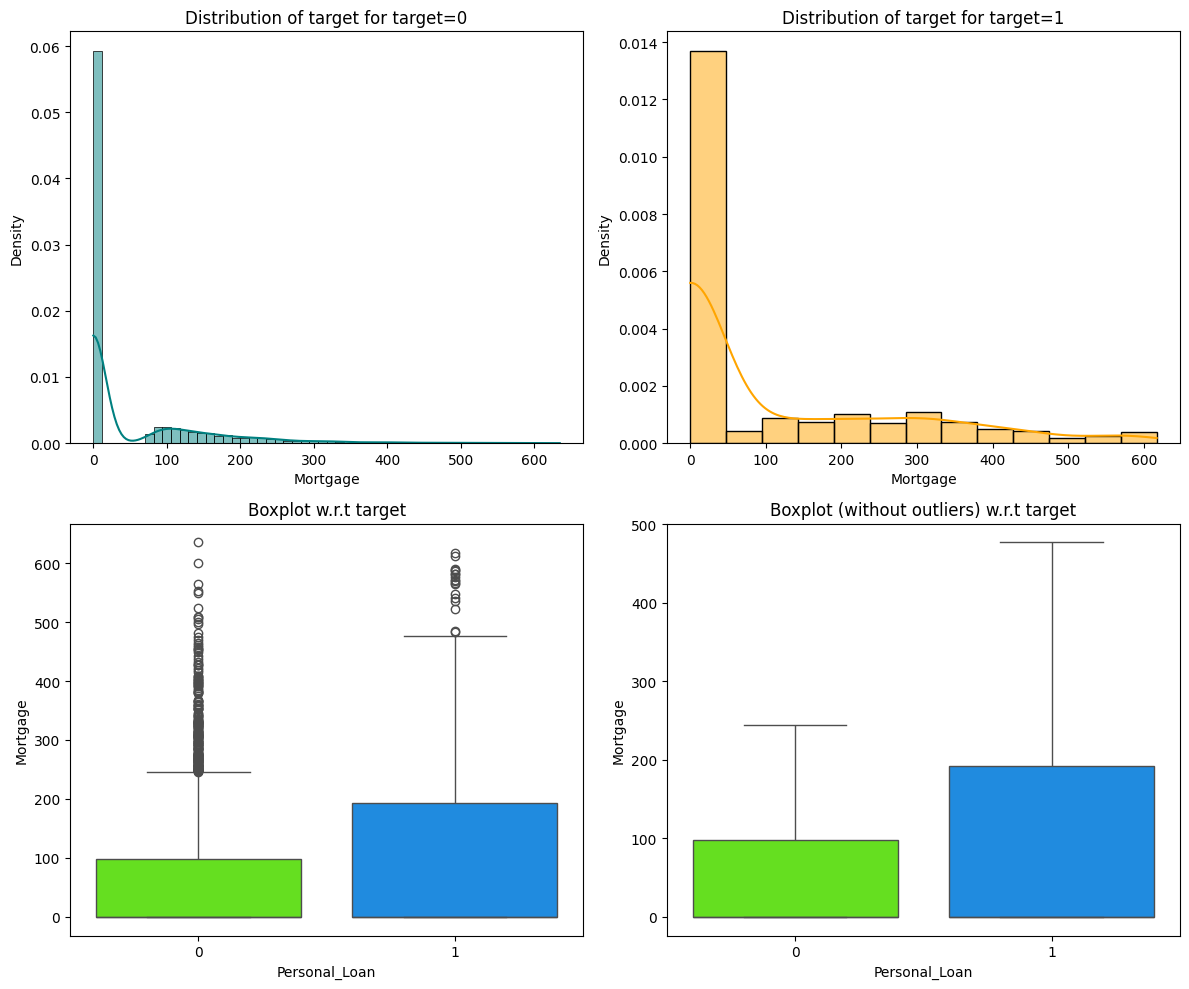

In [229]:
distribution_plot_wrt_target(data, "Mortgage", "Personal_Loan")

Customers with High Mortgage value are likely to take personal loan

**Let's analyze the relation between `Age` and `Personal Loan`.**

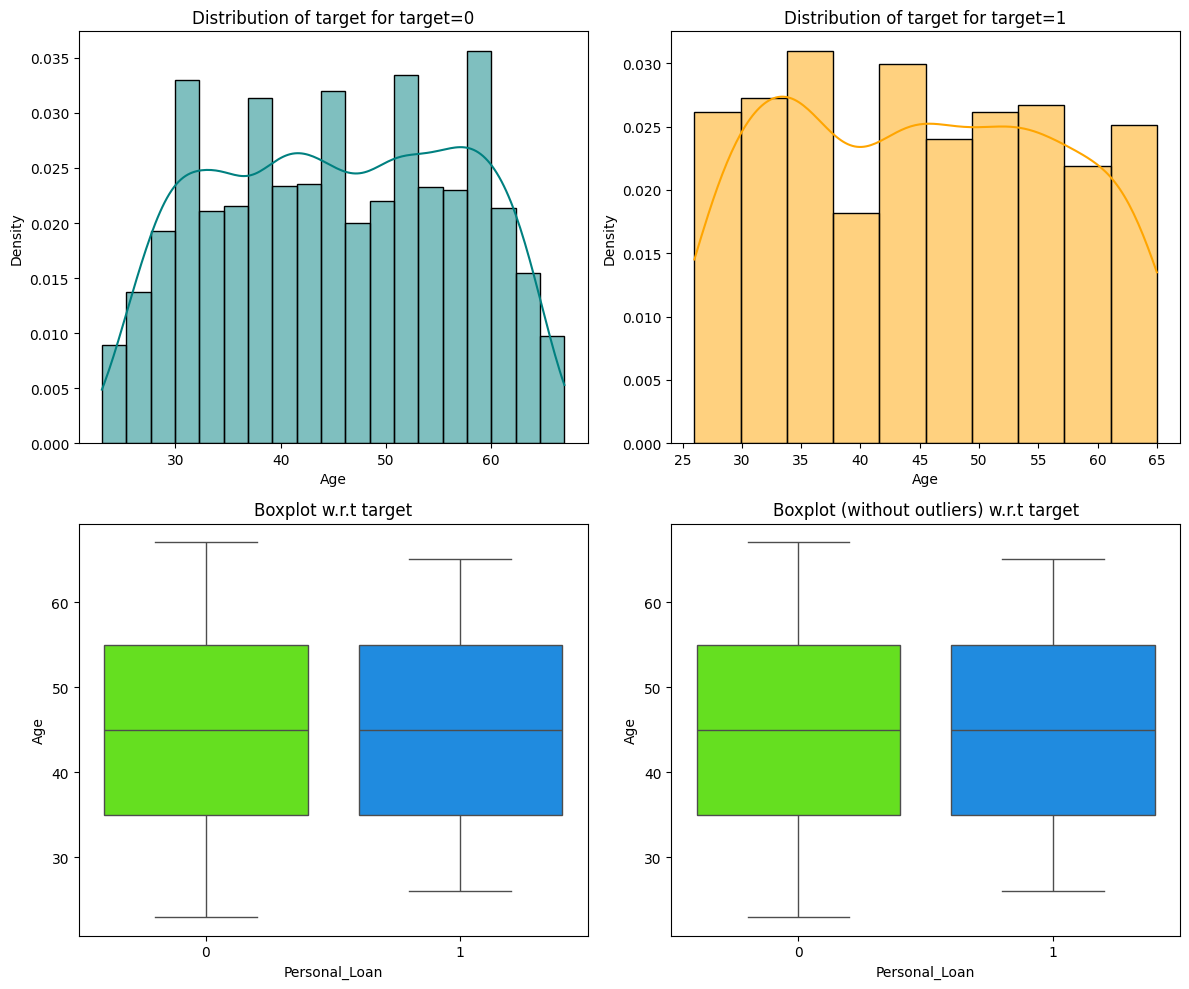

In [230]:
distribution_plot_wrt_target(data, "Age", "Personal_Loan")

Age is not impacting the Personal loan decision.

**Let's analyze the relation between `Experience` and `Personal Loan`.**

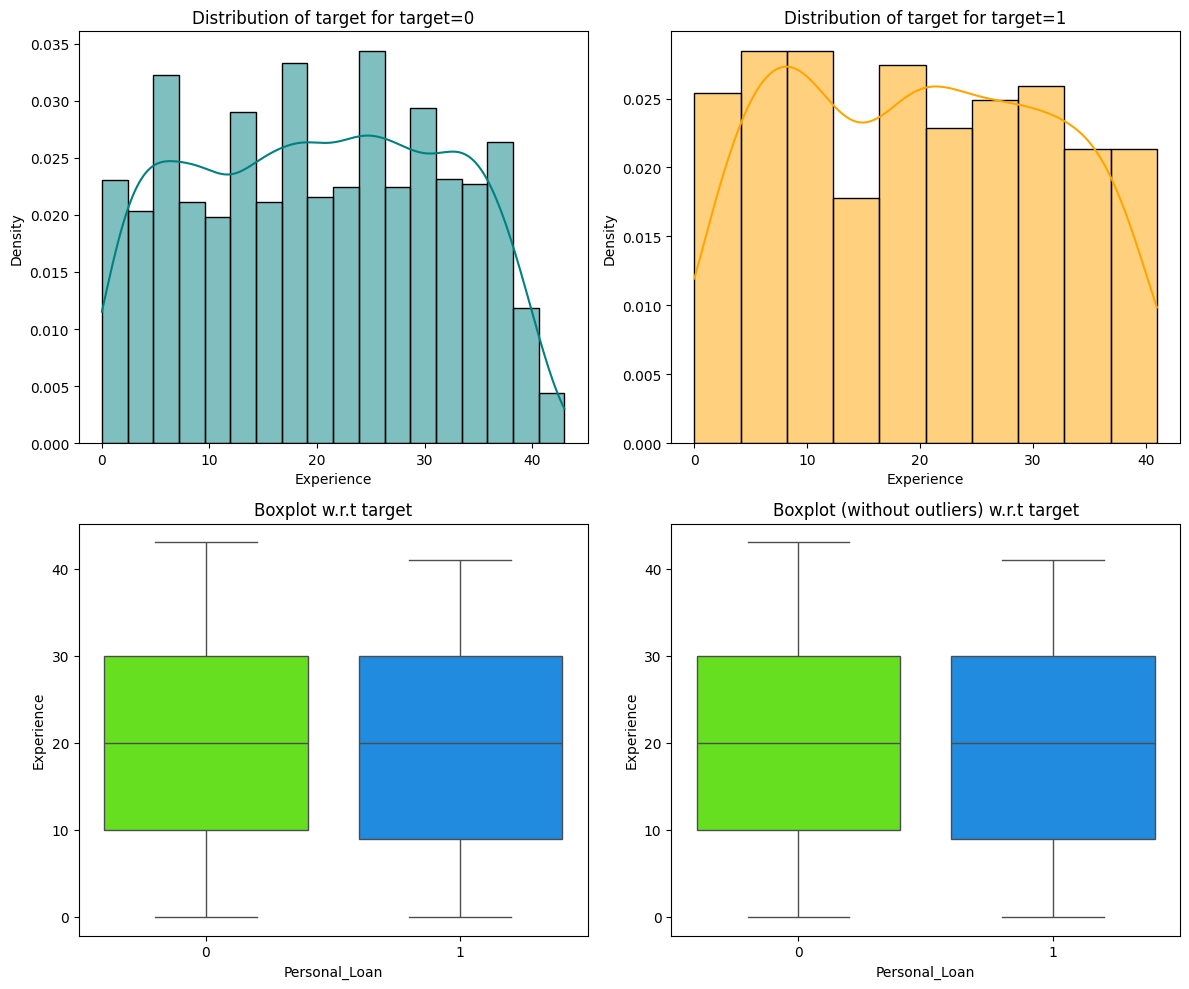

In [231]:
distribution_plot_wrt_target(data, "Experience", "Personal_Loan")

`Experience` is not impacting the Personal loan decision similarly like `Age`

`Conclusions`

* Customers who **spend more on credit cards** are more likely to take out personal loans.

* Customers with **high incomes** are more likely to purchase a personal loan.

* Customers with a **high mortgage** value are more likely to purchase personal loans.

* It can be inferred that the **age of customers has no influence** on the probability of purchasing personal loans.

* It can be inferred that the **Experience of customers has no influence** on the probability of purchasing personal loans. It is inferring similar to **Age**.

* Therefore, **remove Experience** because it **doesn't provide any more information than Age:

In [232]:
data.drop('Experience', axis=1, inplace=True)

In [233]:
# remove other derived columns also

data.drop('State', axis=1, inplace=True)

data.drop('Major_City', axis=1, inplace=True)

data.drop('Education_Label', axis=1, inplace=True)


## Data Preprocessing

### Data Preparation for Modeling

In [234]:
X = data.drop(["Personal_Loan"], axis=1)
Y = data["Personal_Loan"]

X = pd.get_dummies(X, drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=1
)

In [235]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of Personal Loan in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of Personal Loan in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (4000, 11)
Shape of test set :  (1000, 11)
Percentage of Personal Loan in training set:
Personal_Loan
0    0.905
1    0.095
Name: proportion, dtype: float64
Percentage of Personal Loan in test set:
Personal_Loan
0    0.9
1    0.1
Name: proportion, dtype: float64


* We had seen that around 90% of observations belongs to class 0 (Personal Loan not taken) and 10% observations belongs to class 1 (Personal Loan taken), and this is preserved in the train and test sets

* This clearly showing Imbalnced dataset. Imbalanced datasets can lead to algorithms that are biased towards the majority class. This means that any classification algorithm trained on an imbalanced dataset will often inaccurately classify minority classes as the majority class

### Handling Imbalance Dataset

The approach to train test split when dealing with imbalanced datasets is to use stratification. Stratification is an important step in splitting imbalanced datasets into training and test sets. Stratification ensures that the proportion of each class remains the same across both the training and test sets

In [236]:
# re-create test and train models with stratification feature
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1, stratify=Y)

In [237]:
# check the balance of train and test model

print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of Personal Loan in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of Personal Loan in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (4000, 11)
Shape of test set :  (1000, 11)
Percentage of Personal Loan in training set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64
Percentage of Personal Loan in test set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64


the samples are randomly divided in such a way that the proportion of each class remains the same across both the training and test sets.

## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**
- Predicting a customer took personal loan but in reality, the customer didn't take it (FN)
- Predicting a customer didn't took personal loan but in reality, the customer took a loan (FP)

**Which case is more important?**

- If we predict that a customer will not take loan but in reality, the customer will took loan, then the bank will have to loose a potential loan customer due to less advertising or follow-up with customer.
- If we predict that a customer will take loan but in reality, the customer does not take loan, then the bank will have to bear the cost of follow-up and waste time on wrong customer to convert him.

In this project, both are important.

**How to reduce the losses?**

The bank wants to have high accuracy on both re-call and precision. So take F1-Score as important metric.

In [238]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [239]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Decision Tree (default)

In [240]:
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

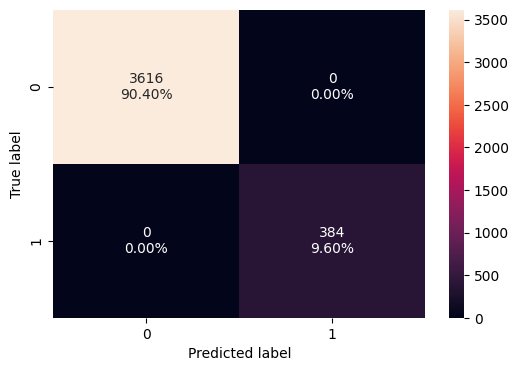

In [241]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [242]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


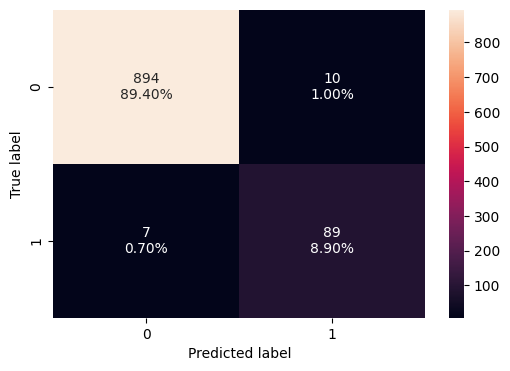

In [243]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [244]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.983,0.927083,0.89899,0.912821


### Decision Tree (with class_weights)

* If the frequency of class 1 (Personal Loan) is 10% and the frequency of class 0  is 90%, then class 0 will become the dominant class and the decision tree will become biased toward the dominant classes

* In this case, we will set class_weight = "balanced", which will automatically adjust the weights to be inversely proportional to the class frequencies in the input data

* class_weight is a hyperparameter for the decision tree classifier

In [245]:
model1 = DecisionTreeClassifier(random_state=1, class_weight="balanced")
model1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

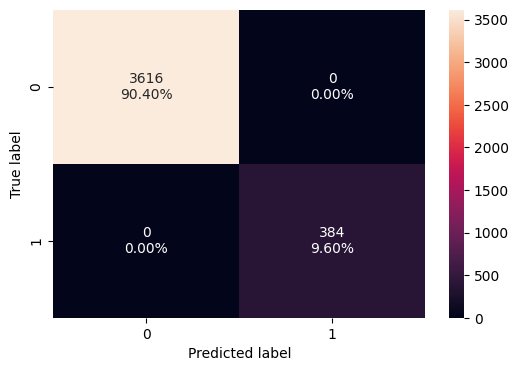

In [246]:
confusion_matrix_sklearn(model1, X_train, y_train)

In [247]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* Model is able to perfectly classify all the data points on the training set.
* 0 errors on the training set, each sample has been classified correctly.
* As we know a decision tree will continue to grow and classify each data point correctly if no restrictions are applied as the trees will learn all the patterns in the training set.
* This generally leads to overfitting of the model as Decision Tree will perform well on the training set but will fail to replicate the performance on the test set.

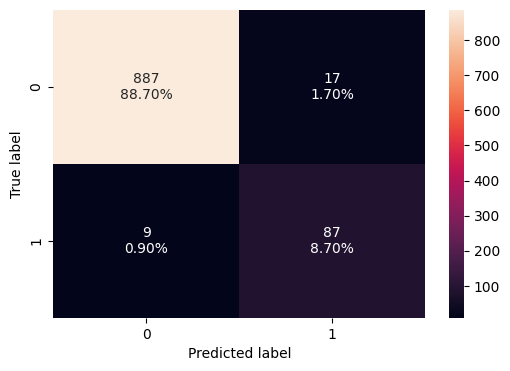

In [248]:
confusion_matrix_sklearn(model1, X_test, y_test)

In [249]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.974,0.90625,0.836538,0.87


* There is a huge disparity in performance of model on training set and test set, which suggests that the model is overfiiting.

**Let's use pruning techniques to try and reduce overfitting.**

### Decision Tree (Pre-pruning)

* Hyperparameter tuning is crucial because it directly affects the performance of a model.
* Unlike model parameters which are learned during training, hyperparameters need to be set before training.
* Effective hyperparameter tuning helps in improving the performance and robustness of the model.
* The below custom loop for hyperparameter tuning iterates over predefined parameter values to identify the best model based on the metric of choice (recall score).

In [250]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(1, 11, 2)
max_leaf_nodes_values = np.arange(3,16,3)
min_samples_split_values = np.arange(2,20,2)

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_f1_score = f1_score(y_train, y_train_pred)
            test_f1_score = f1_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_f1_score - test_f1_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_f1_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_f1_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test F1 Score score: {best_test_score}")

Best parameters found:
Max depth: 5
Max leaf nodes: 9
Min samples split: 2
Best test F1 Score score: 0.7529411764705882


In [251]:
# creating an instance of the best model
model2 = best_estimator

# fitting the best model to the training data
model2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(5),
                       max_leaf_nodes=np.int64(9),
                       min_samples_split=np.int64(2), random_state=42)

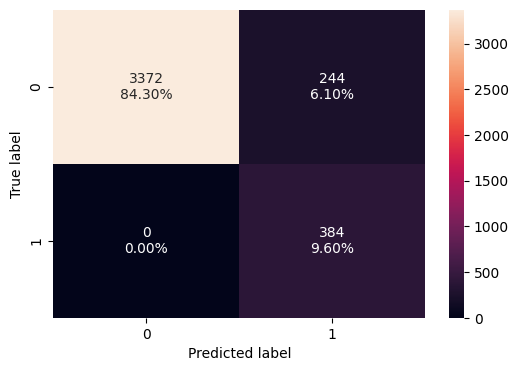

In [252]:
confusion_matrix_sklearn(model2, X_train, y_train)

In [253]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.939,1.0,0.611465,0.758893


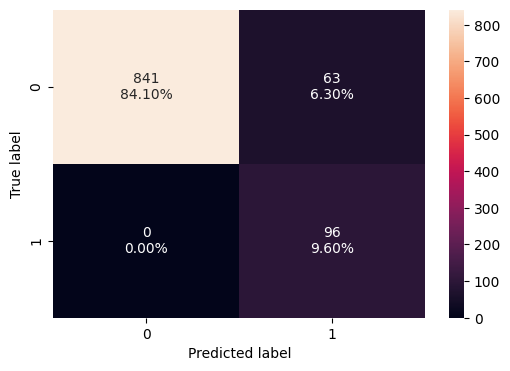

In [254]:
confusion_matrix_sklearn(model2, X_test, y_test)

In [255]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.937,1.0,0.603774,0.752941




* The model is giving a generalized result now since the F1 scores on both the train and test data are coming to be around 0.5 which shows that the model is able to generalize well on unseen data.

In [256]:
feature_names = list(X_train.columns)
importances = model2.feature_importances_
indices = np.argsort(importances)

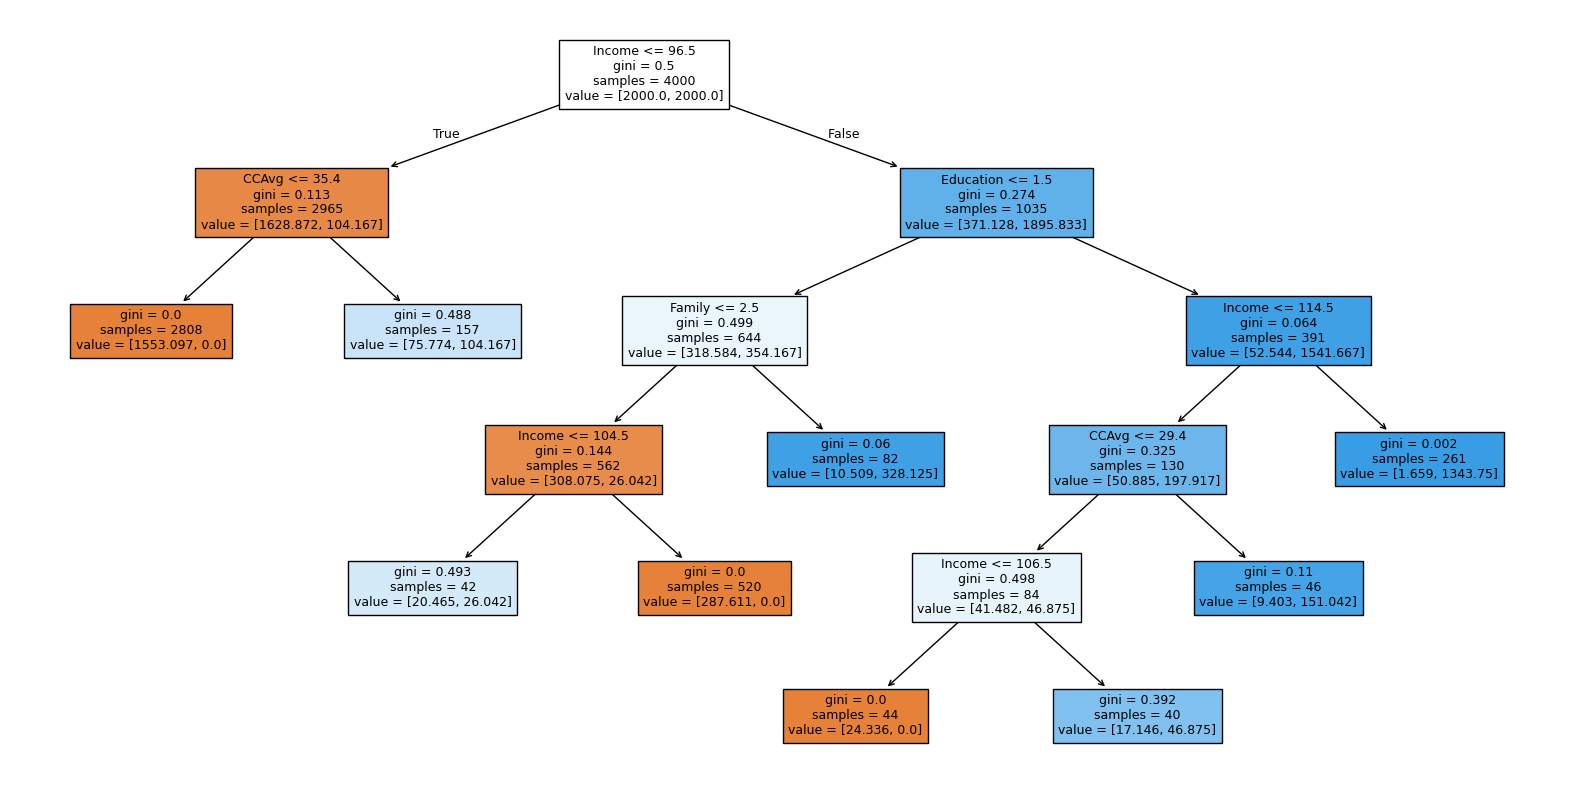

In [257]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()


In [258]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

|--- Income <= 96.50
|   |--- CCAvg <= 35.40
|   |   |--- weights: [1553.10, 0.00] class: 0
|   |--- CCAvg >  35.40
|   |   |--- weights: [75.77, 104.17] class: 1
|--- Income >  96.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- weights: [20.46, 26.04] class: 1
|   |   |   |--- Income >  104.50
|   |   |   |   |--- weights: [287.61, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [10.51, 328.12] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 114.50
|   |   |   |--- CCAvg <= 29.40
|   |   |   |   |--- Income <= 106.50
|   |   |   |   |   |--- weights: [24.34, 0.00] class: 0
|   |   |   |   |--- Income >  106.50
|   |   |   |   |   |--- weights: [17.15, 46.88] class: 1
|   |   |   |--- CCAvg >  29.40
|   |   |   |   |--- weights: [9.40, 151.04] class: 1
|   |   |--- Income >  114.50
|   |   |   |--- weights: [1.66, 1343.75] class: 1



Using the above extracted decision rules we can make interpretations from the decision tree model like:

**Summary**
* The most critical factors influencing personal loan acceptance are Income and CCAvg. Customers with higher incomes are generally good candidates. For those with moderate incomes, high credit card spending is a key indicator. Education level and family size further refine these predictions, especially for higher-income segments.

**Note**: Interpretations from other decision rules can be made similarly.

In [259]:
importances = model2.feature_importances_
importances

array([0.        , 0.6828908 , 0.        , 0.14649787, 0.06984587,
       0.10076546, 0.        , 0.        , 0.        , 0.        ,
       0.        ])

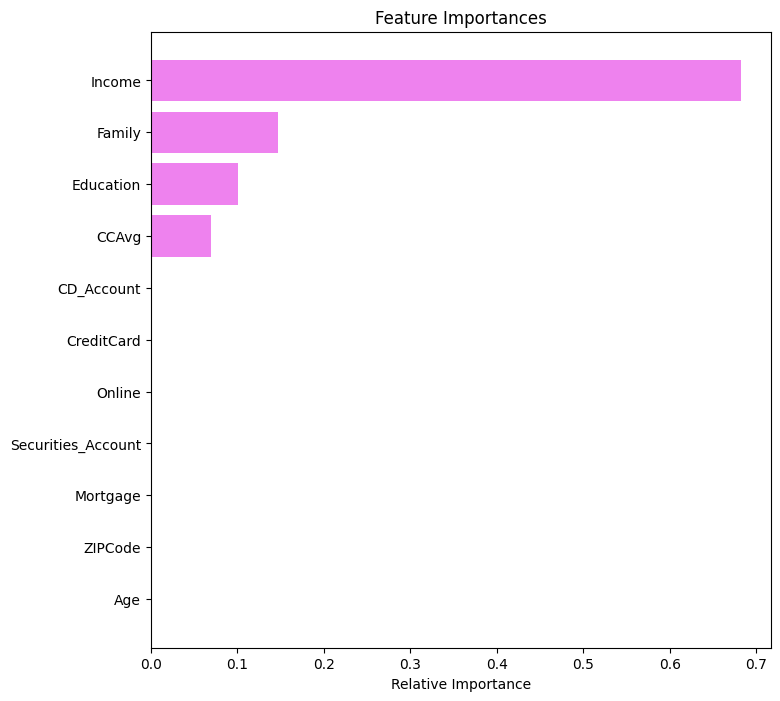

In [260]:
# importance of features in the tree building

importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [261]:
importances = model2.feature_importances_
importances

array([0.        , 0.6828908 , 0.        , 0.14649787, 0.06984587,
       0.10076546, 0.        , 0.        , 0.        , 0.        ,
       0.        ])

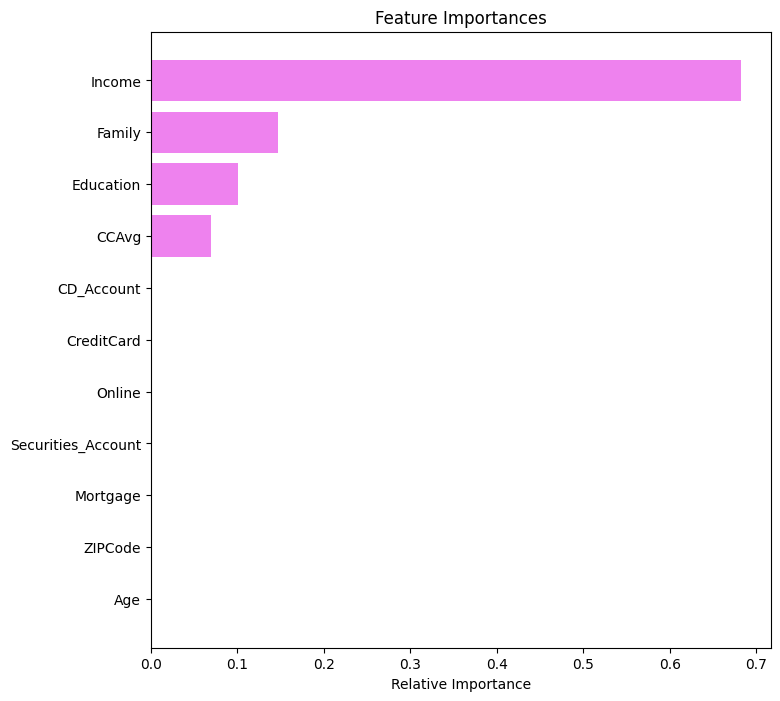

In [262]:
# importance of features in the tree building

importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* In the pre-pruned decision tree:  income, family, Education and Credit card spend average are the most important features.

### Decision Tree (Post pruning)

- Cost complexity pruning provides another option to control the size of a tree.
- In `DecisionTreeClassifier`, this pruning technique is parameterized by the
cost complexity parameter, ``ccp_alpha``.
- Greater values of ``ccp_alpha`` increase the number of nodes pruned.
- Here we only show the effect of ``ccp_alpha`` on regularizing the trees and how to choose the optimal ``ccp_alpha`` value.

**Total impurity of leaves vs effective alphas of pruned tree**

Minimal cost complexity pruning recursively finds the node with the "weakest
link". The weakest link is characterized by an effective alpha, where the
nodes with the smallest effective alpha are pruned first. To get an idea of
what values of ``ccp_alpha`` could be appropriate, scikit-learn provides
`DecisionTreeClassifier.cost_complexity_pruning_path` that returns the
effective alphas and the corresponding total leaf impurities at each step of
the pruning process. As alpha increases, more of the tree is pruned, which
increases the total impurity of its leaves.

In [263]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [264]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-1.469475e-16
1,9.210921e-20,-1.468553e-16
2,9.210921e-20,-1.467632e-16
3,1.765427e-18,-1.449978e-16
4,2.701870e-18,-1.422959e-16
5,3.392689e-18,-1.389032e-16
6,3.469447e-18,-1.354338e-16
7,6.524402e-18,-1.289094e-16
8,2.471981e-17,-1.041896e-16
9,2.315012e-16,1.273116e-16


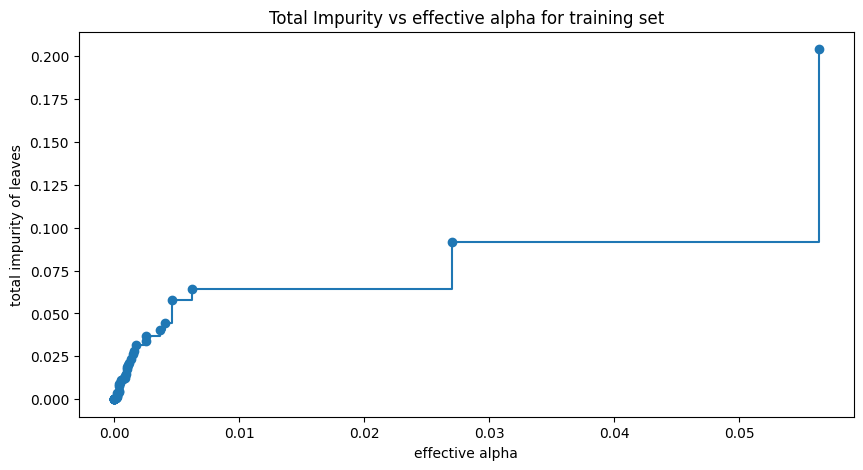

In [265]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using the effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [266]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.29586208626918736


For the remainder, we remove the last element in
``clfs`` and ``ccp_alphas``, because it is the trivial tree with only one
node. Here we show that the number of nodes and tree depth decreases as alpha
increases.

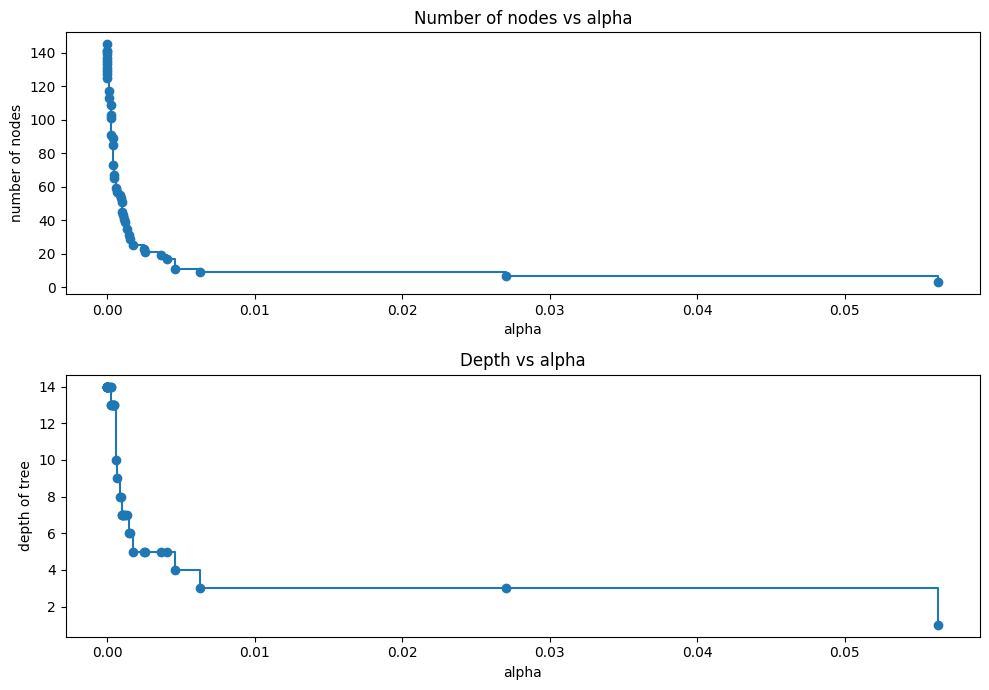

In [267]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [268]:
f1_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = f1_score(y_train, pred_train)
    f1_train.append(values_train)

In [269]:
f1_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = f1_score(y_test, pred_test)
    f1_test.append(values_test)

In [270]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

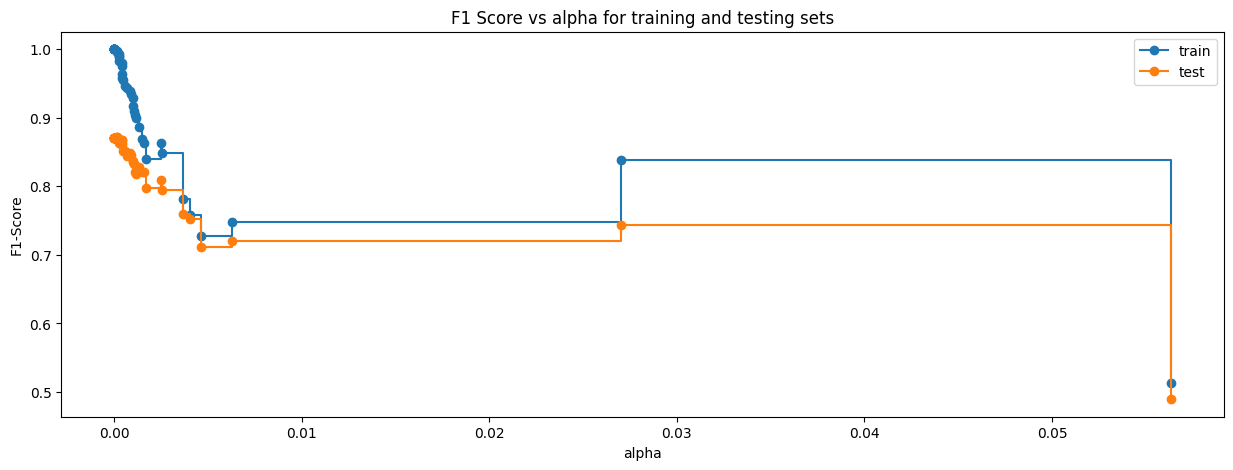

In [271]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("F1-Score")
ax.set_title("F1 Score vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, f1_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, f1_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [272]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(f1_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0001353986135181967),
                       class_weight='balanced', random_state=1)


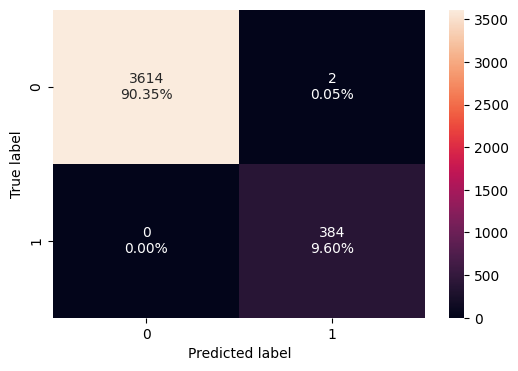

In [273]:
model4 = best_model
confusion_matrix_sklearn(model4, X_train, y_train)

In [274]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model4, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.9995,1.0,0.994819,0.997403


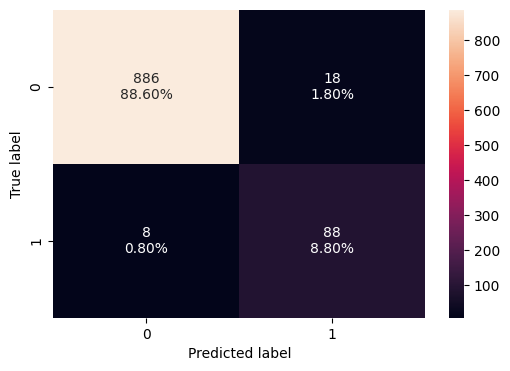

In [275]:
confusion_matrix_sklearn(model4, X_test, y_test)

In [276]:
decision_tree_post_test = model_performance_classification_sklearn(
    model4, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.974,0.916667,0.830189,0.871287


* In the post-pruned tree also, the model is giving a generalized result since the f1 scores on both the train and test data are coming to be around 0.90 which shows that the model is able to generalize well on unseen data.

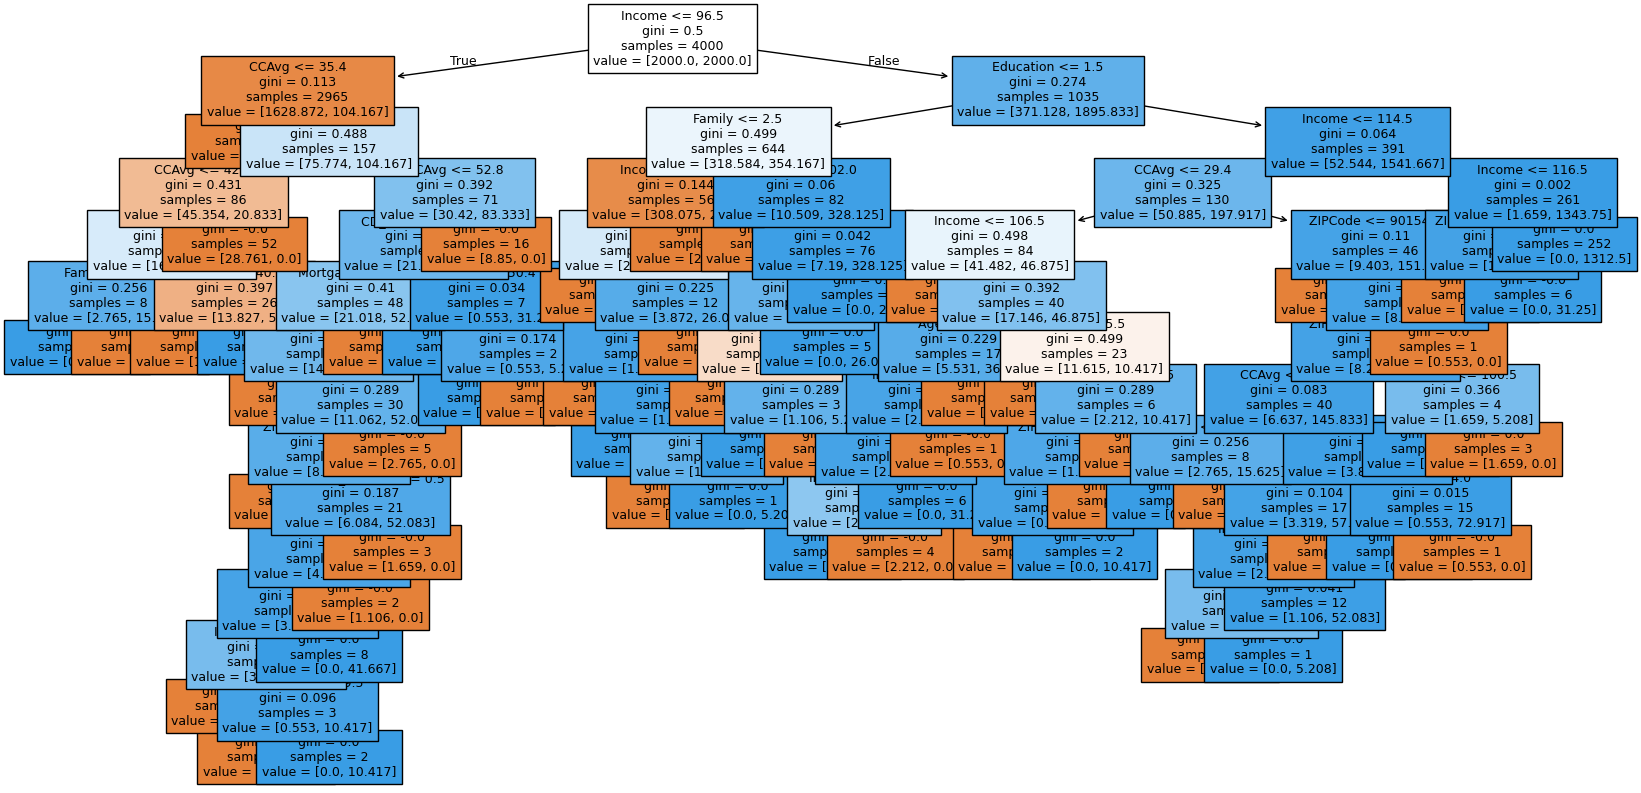

In [277]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model4,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [278]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model4, feature_names=feature_names, show_weights=True))


|--- Income <= 96.50
|   |--- CCAvg <= 35.40
|   |   |--- weights: [1553.10, 0.00] class: 0
|   |--- CCAvg >  35.40
|   |   |--- Income <= 81.50
|   |   |   |--- CCAvg <= 42.60
|   |   |   |   |--- Age <= 37.50
|   |   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |   |--- weights: [0.00, 15.62] class: 1
|   |   |   |   |   |--- Family >  3.50
|   |   |   |   |   |   |--- weights: [2.77, 0.00] class: 0
|   |   |   |   |--- Age >  37.50
|   |   |   |   |   |--- CCAvg <= 40.20
|   |   |   |   |   |   |--- weights: [13.83, 0.00] class: 0
|   |   |   |   |   |--- CCAvg >  40.20
|   |   |   |   |   |   |--- weights: [0.00, 5.21] class: 1
|   |   |   |--- CCAvg >  42.60
|   |   |   |   |--- weights: [28.76, 0.00] class: 0
|   |   |--- Income >  81.50
|   |   |   |--- CCAvg <= 52.80
|   |   |   |   |--- CD_Account <= 0.50
|   |   |   |   |   |--- Mortgage <= 104.50
|   |   |   |   |   |   |--- CCAvg <= 36.60
|   |   |   |   |   |   |   |--- weights: [3.32, 0.00] class: 0
|   |   |   |  

- We can see that the observation Post pruning training is over fitted and its not working good in Test dataset

In [279]:
importances = model4.feature_importances_
indices = np.argsort(importances)

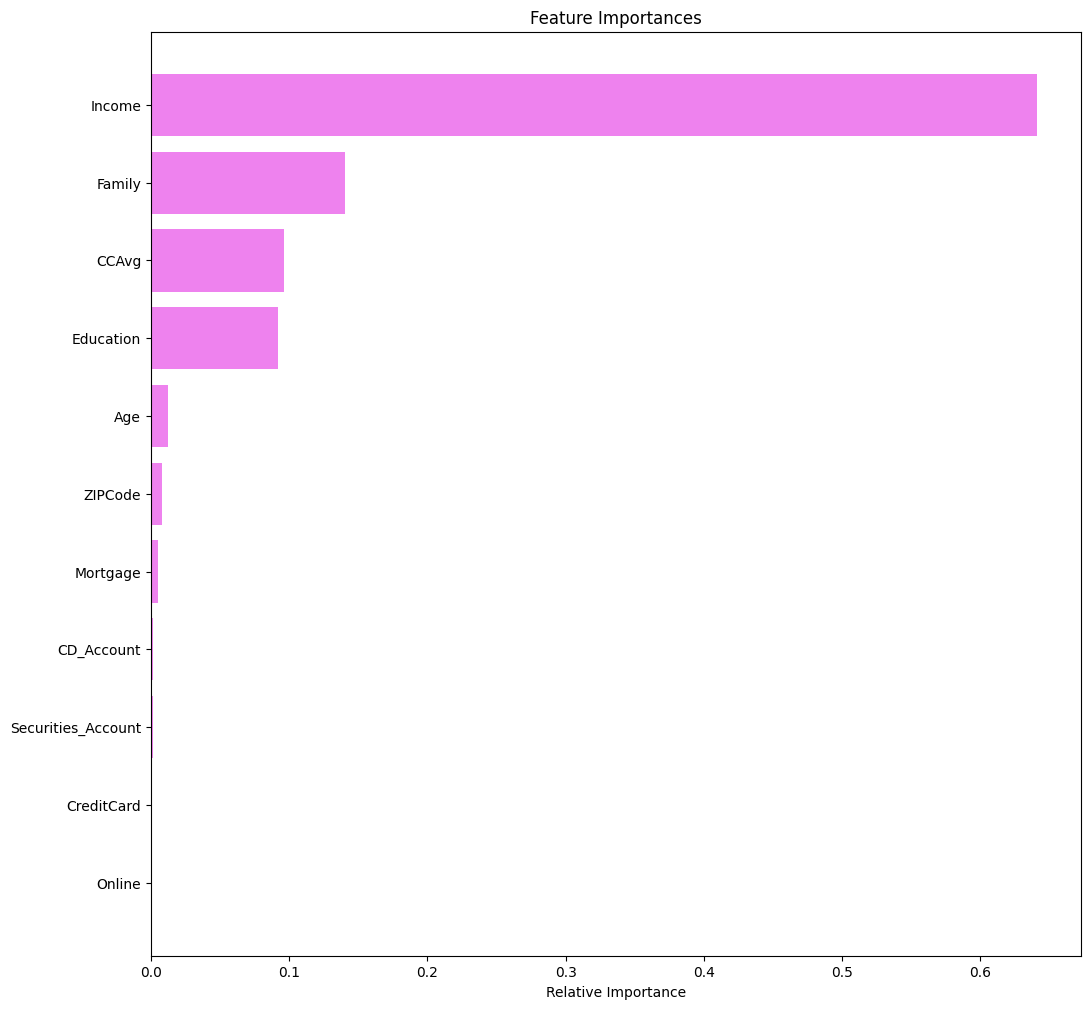

In [280]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Income and Credit Card spend, family & Education are the most important features for the post pruned tree

## Comparison of Models and Final Model Selection

In [281]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.939000,0.999500
Recall,1.0,1.0,1.000000,1.000000
Precision,1.0,1.0,0.611465,0.994819
F1,1.0,1.0,0.758893,0.997403


In [282]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.983000,0.974000,0.937000,0.974000
Recall,0.927083,0.906250,1.000000,0.916667
Precision,0.898990,0.836538,0.603774,0.830189
F1,0.912821,0.870000,0.752941,0.871287


* Decision tree models with post-pruning is overfitted and not performaing in test data (unknown data).
* Decision tree models with pre-pruning is normalized both in test and train data with 75% accurecy in F1Score.
* Therefore, we are choosing the post-pruned tree as our best model.

## Conclusions and Recommendations

- The model built can be used to predict if a customer can take loan  or not and can correctly identify 75%

- Income, CC_Avg, Education & Family are the most important variables in predicting whether a customer take a loan or not


- From the decision tree,

* Income is the Most Dominant Factor: Customers with higher incomes (generally above 96.50 thousand dollars) are significantly more likely to accept a personal loan. This is evident in multiple paths leading to class: 1 when Income is high.

* CCAvg is Crucial for Lower/Mid-Income Customers: For customers with lower or moderate incomes (less than or equal to 96.50 thousand dollars), their average credit card spending (CCAvg) becomes a critical differentiator. Those with high CCAvg (above 35.40 thousand dollars) are more inclined to take a personal loan, while those with low CCAvg are not.

* Education and Family Size Refine Predictions for High-Income Earners: For customers with high incomes (above 96.50 thousand dollars):

* If they have a higher education level (Graduate or Advanced/Professional, Education > 1.50), they are generally very likely to accept a loan, especially if their income is very high (above 114.50 thousand dollars) or their CCAvg is also high.
* If they have an undergraduate education (Education <= 1.50), a larger family size (Family > 2.50) makes them more prone to taking a loan.
Exception for Very High Income, Undergrad, Small Family: There's an interesting branch indicating that customers with very high income (Income > 104.50), who are undergraduates (Education <= 1.50) and have small families (Family <= 2.50), are less likely to accept a loan (class: 0). This suggests a specific segment that might not need or want a personal loan despite high income.